In [ ]:
"""import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))"""

# Installing required python libraries

In [ ]:
!pip install duckdb --no-index --find-links=file:///kaggle/input/polars-and-duckdb/kaggle/working/mysitepackages/duck_pkg
!pip install polars[numpy,pandas,pyarrow] --no-index --find-links=file:///kaggle/input/polars-and-duckdb/kaggle/working/mysitepackages/polars_pkg
!pip install plotly
!pip install librosa
!pip install -U imbalanced-learn==0.12.4

In [1]:
!pip install -U scikit-learn==1.5.0
!pip install -U imbalanced-learn==0.13.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 91.3 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 5.0 MB/s eta 0:00:0000:01
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.12.4
    Uninstalling imbalanced-learn-0.12.4:
      Successfully uninstalled imbalanced-learn-0.12.4


In [3]:
!pip install --upgrade scikit-learn imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 84.4 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.6.1 which is incompatible.
bigframes 1.36.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.


In [2]:
import sklearn
import imblearn

print("scikit-learn version:", sklearn.__version__)
print("imblearn version:", imblearn.__version__)

scikit-learn version: 1.5.0
imblearn version: 0.13.0


In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import duckdb as dd
import polars as pl
import pyarrow
import os
import glob
import shutil
import zipfile
import matplotlib.pyplot as plt
plt.style.use('dark_background')
import seaborn as sns
import plotly.express as px
import librosa
import pickle
from joblib import dump, load
from pathlib import Path
from IPython.display import Audio
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

"""import tensorflow as tf
import tensorflow_io as tfio
from tensorflow import keras

import cudf
import cuml
from cuml.svm import SVC
from cuml.model_selection import train_test_split
from cuml.metrics import accuracy_score"""

'import tensorflow as tf\nimport tensorflow_io as tfio\nfrom tensorflow import keras\n\nimport cudf\nimport cuml\nfrom cuml.svm import SVC\nfrom cuml.model_selection import train_test_split\nfrom cuml.metrics import accuracy_score'

In [2]:
# Path to the directory containing your audio dataset
dataset_dir = '/kaggle/input/birdclef-2025/train_audio'
# Initialize an empty dictionary to store the mapping between audio files and labels
label_mapping = {}
# Iterate over subdirectories (classes) in the dataset directory
for label in os.listdir(dataset_dir):
    label_dir = os.path.join(dataset_dir, label)
    # Check if the item in the dataset directory is a directory
    if os.path.isdir(label_dir):
        # Iterate over audio files in the subdirectory (class)
        for audio_file in os.listdir(label_dir):
            # Add the mapping between audio file path and label to the dictionary
            audio_file_path = os.path.join(label_dir, audio_file)
            label_mapping[audio_file_path] = label
            
# label_mapping

# Create a list of tuples containing the audio file paths and labels
data = [(audio_file_path, label) for audio_file_path, label in label_mapping.items()]
# Create a Pandas DataFrame from the list of tuples
annotated_data = pd.DataFrame(data, columns=['audio_file_path', 'label'])

label_encoder = LabelEncoder()
annotated_data['encoded_label'] = label_encoder.fit_transform(annotated_data['label'])

print("dataset size: ",annotated_data.shape)

dataset size:  (28564, 3)


In [3]:
annotated_data.head(5)

,audio_file_path,label,encoded_label
0,/kaggle/input/birdclef-2025/train_audio/greani...,greani1,110
1,/kaggle/input/birdclef-2025/train_audio/greani...,greani1,110
2,/kaggle/input/birdclef-2025/train_audio/greani...,greani1,110
3,/kaggle/input/birdclef-2025/train_audio/greani...,greani1,110
4,/kaggle/input/birdclef-2025/train_audio/greani...,greani1,110


In [3]:
pl.Config(tbl_rows=200)
dd.sql("select * from \
    (select label, files, row_number()over(order by files desc) as rn from \
        (select label, count(distinct(audio_file_path)) as files from annotated_data group by label \
        )t1 \
    )t2 where rn <= 100").pl()

label,files,rn
str,i64,i64
"""grekis""",990,1
"""compau""",808,2
"""trokin""",787,3
"""roahaw""",709,4
"""banana""",610,5
"""whtdov""",572,6
"""socfly1""",543,7
"""yeofly1""",525,8
"""bobfly1""",514,9


In [12]:
def audio_waveframe(file_path):
    # Load the audio file
    audio_data, sampling_rate = librosa.load(file_path)
    # Calculate the duration of the audio file
    duration = len(audio_data) / sampling_rate
    # Create a time array for plotting
    time = np.arange(0, duration, 1/sampling_rate)
    # Plot the waveform
    plt.figure(figsize=(30, 4))
    plt.plot(time, audio_data, color='blue')
    plt.title('Audio Waveform')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plot = plt.show()
    return plot

def spectrogram(file_path):
    # Compute the short-time Fourier transform (STFT)
    n_fft = 500  # Number of FFT points 2048
    hop_length = 50  # Hop length for STFT 512
    audio_data, sampling_rate = librosa.load(file_path)
    stft = librosa.stft(audio_data, n_fft=n_fft, hop_length=hop_length)
    # Convert the magnitude spectrogram to decibels (log scale)
    spectrogram = librosa.amplitude_to_db(np.abs(stft))
    # Plot the spectrogram
    plt.figure(figsize=(30, 6))
    librosa.display.specshow(spectrogram, sr=sampling_rate, hop_length=hop_length, x_axis='time', y_axis='linear')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Spectrogram')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.tight_layout()
    plot = plt.show()
    return plot

def audio_analysis(file_path):
    aw = audio_waveframe(file_path)
    spg = spectrogram(file_path)
    return aw, spg

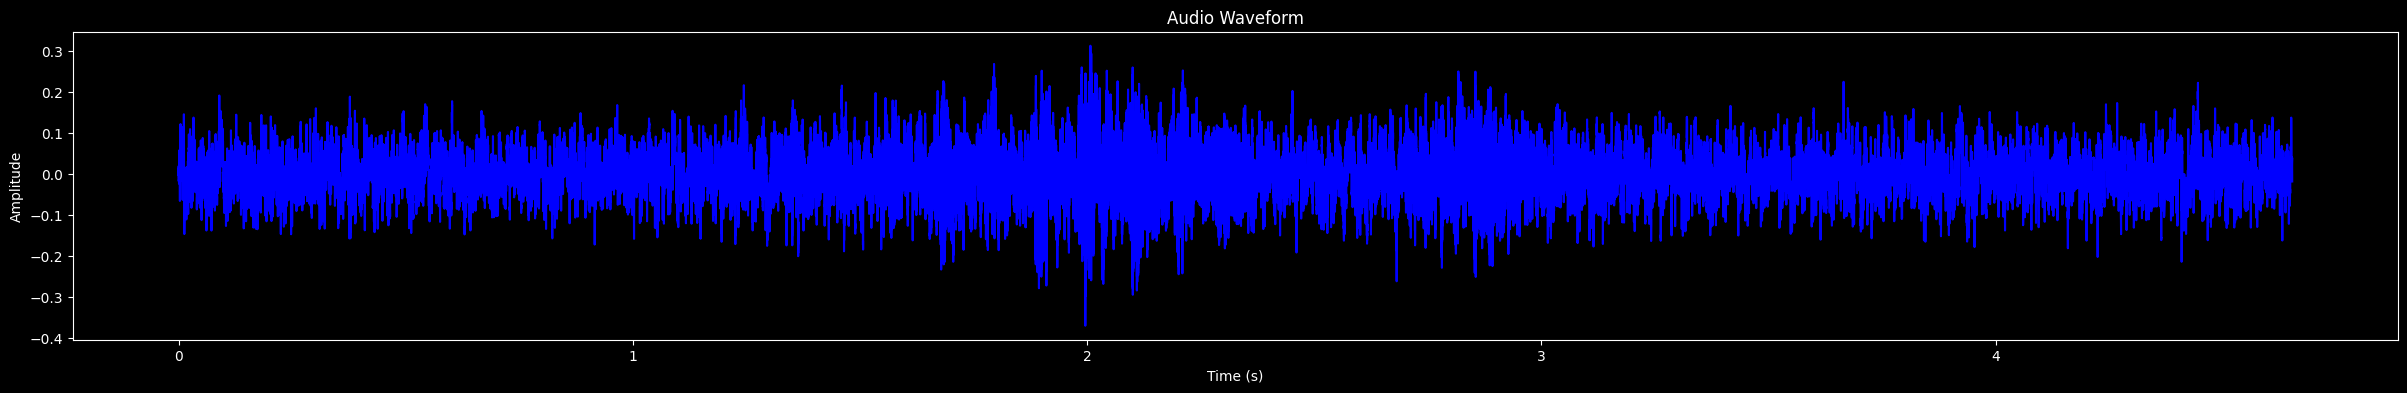

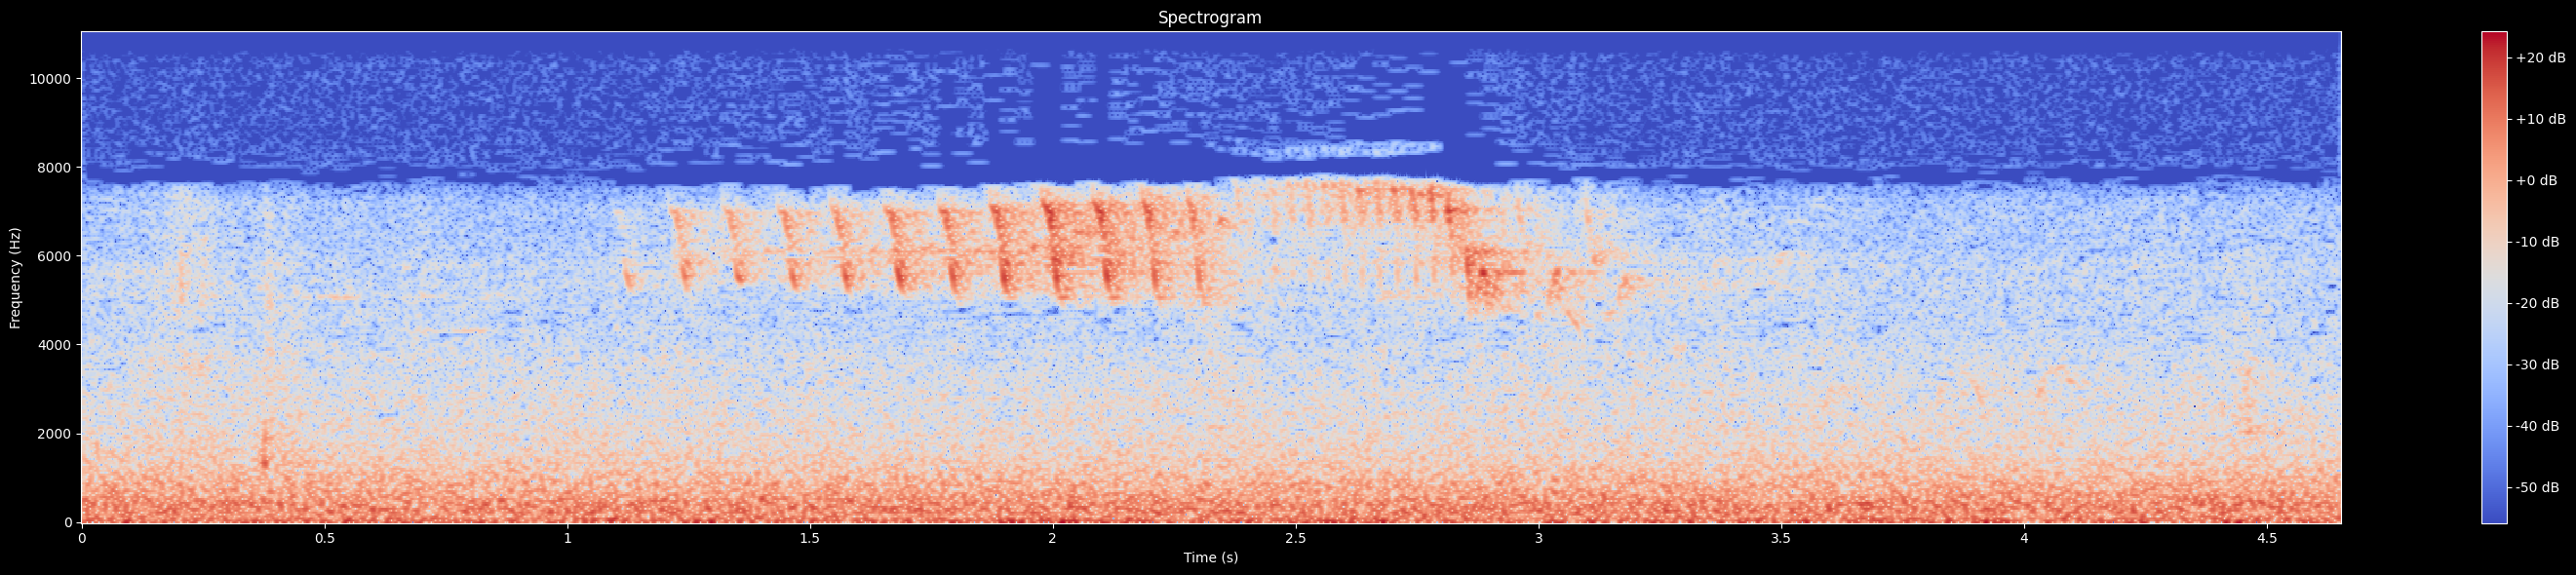

In [13]:
audio_analysis('/kaggle/input/birdclef-2025/train_audio/tropar/iNat394911.ogg')
y, sr = librosa.load('/kaggle/input/birdclef-2025/train_audio/tropar/iNat394911.ogg')
Audio(y, rate=sr)

# Get the metadata

In [4]:
meta_data_schema = {
    "primary_label": pl.String,
    "secondary_labels": pl.String,
    "type": pl.String,
    "filename": pl.String,
    "collection": pl.String,
    "rating": pl.Float64,
    "url": pl.String,
    "latitude": pl.Float64,
    "longitude": pl.Float64,
    "scientific_name": pl.String,
    "common_name": pl.String,
    "author": pl.String,
    "license": pl.String
}

meta_data = pl.read_csv('/kaggle/input/birdclef-2025/train.csv',has_header=True, schema=meta_data_schema
                        , low_memory=True, null_values=["NA", "", "null","None"])

meta_data = meta_data.with_columns(
    pl.concat_str([pl.lit('/kaggle/input/birdclef-2025/train_audio/'),pl.col('filename')],separator='')\
                                   .alias('filename'))

#meta_data = meta_data.select(pl.exclude('filename'))

#meta_data = meta_data.rename({"full_file_path": "filename"})

meta_data.head(5)

primary_label,secondary_labels,type,filename,collection,rating,url,latitude,longitude,scientific_name,common_name,author,license
str,str,str,str,str,f64,str,f64,f64,str,str,str,str
"""1139490""","""['']""","""['']""","""/kaggle/input/birdclef-2025/tr…","""CSA""",0.0,"""http://colecciones.humboldt.or…",7.3206,-73.7128,"""Ragoniella pulchella""","""Ragoniella pulchella""","""Fabio A. Sarria-S""","""cc-by-nc-sa 4.0"""
"""1139490""","""['']""","""['']""","""/kaggle/input/birdclef-2025/tr…","""CSA""",0.0,"""http://colecciones.humboldt.or…",7.3206,-73.7128,"""Ragoniella pulchella""","""Ragoniella pulchella""","""Fabio A. Sarria-S""","""cc-by-nc-sa 4.0"""
"""1192948""","""['']""","""['']""","""/kaggle/input/birdclef-2025/tr…","""CSA""",0.0,"""http://colecciones.humboldt.or…",7.3791,-73.7313,"""Oxyprora surinamensis""","""Oxyprora surinamensis""","""Fabio A. Sarria-S""","""cc-by-nc-sa 4.0"""
"""1192948""","""['']""","""['']""","""/kaggle/input/birdclef-2025/tr…","""CSA""",0.0,"""http://colecciones.humboldt.or…",7.28,-73.8582,"""Oxyprora surinamensis""","""Oxyprora surinamensis""","""Fabio A. Sarria-S""","""cc-by-nc-sa 4.0"""
"""1192948""","""['']""","""['']""","""/kaggle/input/birdclef-2025/tr…","""CSA""",0.0,"""http://colecciones.humboldt.or…",7.3791,-73.7313,"""Oxyprora surinamensis""","""Oxyprora surinamensis""","""Fabio A. Sarria-S""","""cc-by-nc-sa 4.0"""


# Remove the recordings that have human voice

In [5]:
author_map = {
    'Alexandra Butrago-Cardona': 'Alexandra Buitrago-Cardona',
    'Ana María Ospina-Larrea | Daniela Murillo': 'Ana María Ospina-Larrea',
    'Diego A Gómez-Morales': 'Diego A. Gomez-Morales',
    'Eliana Barona- Cortés': 'Eliana Barona-Cortés',
    'Eliana Barona-Cortés | Daniela García-Cobos': 'Eliana Barona-Cortés',
    'Paula Caycedo-Rosales | Juan-Pablo López': 'Paula Caycedo-Rosales',
    'Fabio A. Sarria-S': 'Fabio A. Sarria-S'
}

sounds_to_exclude = meta_data.filter(
    pl.col("author").is_in (list(author_map.keys()))
)

In [7]:
dd.sql("select * from sounds_to_exclude where filename = '/kaggle/input/birdclef-2025/train_audio/1139490/CSA36385.ogg'").pl()

primary_label,secondary_labels,type,filename,collection,rating,url,latitude,longitude,scientific_name,common_name,author,license
str,str,str,str,str,f64,str,f64,f64,str,str,str,str
"""1139490""","""['']""","""['']""","""/kaggle/input/birdclef-2025/tr…","""CSA""",0.0,"""http://colecciones.humboldt.or…",7.3206,-73.7128,"""Ragoniella pulchella""","""Ragoniella pulchella""","""Fabio A. Sarria-S""","""cc-by-nc-sa 4.0"""


In [ ]:
dd.sql('select collection, count(distinct(filename)) as file_count from sounds_to_exclude group by collection order by 2 desc').pl()

In [ ]:
pl.Config(tbl_rows=200)
dd.sql("select * from (select author, file_count, row_number()over(order by file_count desc) rn \
from (select author, count(distinct(filename)) as file_count from sounds_to_exclude \
group by author)t1)t2 where rn <= 50 order by file_count desc"\
      ).pl()

In [42]:
dd.sql("select distinct primary_label from sounds_to_exclude").pl()

primary_label
str
"""1462737"""
"""24292"""
"""1462711"""
"""528041"""
"""52884"""
…
"""1139490"""
"""1192948"""
"""1194042"""


In [6]:
final_train_df = dd.sql("select t1.* \
    from annotated_data t1 \
    left join sounds_to_exclude t2 \
    on t1.audio_file_path = t2.filename \
    where t2.author is null").pl()

# Arrive at the final training dataset

In [7]:
final_train_df.shape

(28523, 3)

In [44]:
dd.sql("select distinct ad.label from annotated_data ad left join final_train_df ftd on ad.label = ftd.label \
where ftd.label is null").pl()

label
str
"""24292"""
"""1462737"""
"""963335"""
"""1192948"""
"""1139490"""
"""1462711"""
"""64862"""
"""528041"""


In [48]:
late_inclusion = dd.sql("select * from annotated_data where label in (select distinct ad.label from annotated_data ad \
left join final_train_df ftd on ad.label = ftd.label where ftd.label is null)").pl()

In [49]:
labels = []
features = []

# Loop through each audio file in the dataset directory
for i in range(late_inclusion.shape[0]):
    file_path = late_inclusion.item(i,0)
    audio, sample_rate = librosa.load(file_path, sr=32000)
    samples_per_segment = sample_rate * 5
    if len(audio) > 7680000:
        total_samples = 7680000
    else:
        total_samples = len(audio)

    for j in range(0, total_samples+160000, samples_per_segment):
        if j + samples_per_segment <= total_samples:
            segment = audio[j:j + samples_per_segment]
            mfccs = librosa.feature.mfcc(y=segment, sr=32000, n_mfcc=40)
            flattened_features = (np.mean(mfccs.T, axis=0))
            features.append(flattened_features)
            labels.append(late_inclusion.item(i,2))

In [8]:
final_train_df.tail(5)

audio_file_path,label,encoded_label
str,str,i64
"""/kaggle/input/birdclef-2025/tr…","""wbwwre1""",185
"""/kaggle/input/birdclef-2025/tr…","""wbwwre1""",185
"""/kaggle/input/birdclef-2025/tr…","""wbwwre1""",185
"""/kaggle/input/birdclef-2025/tr…","""wbwwre1""",185
"""/kaggle/input/birdclef-2025/tr…","""wbwwre1""",185


In [23]:
dd.sql("select label, count(distinct(audio_file_path)) as file_count \
from final_train_df group by label having count(distinct(audio_file_path)) < 70 order by 2").pl()

label,file_count
str,i64
"""476537""",1
"""21038""",2
"""47067""",2
"""21116""",2
"""42087""",2
…,…
"""palhor2""",66
"""cinbec1""",67
"""grepot1""",67


In [25]:
file_path = final_train_df.item(200,0)
audio, sample_rate = librosa.load(file_path, sr=32000)
samples_per_segment = sample_rate * 5
len(audio)

1036539

In [21]:
samples_per_segment

160000

In [27]:
labels = []
features = []

total_samples = len(audio)
for j in range(0, total_samples+160000, samples_per_segment):
    print(j)
    if j + samples_per_segment <= total_samples:
        segment = audio[j:j + samples_per_segment]
        print(segment)
        mfccs = librosa.feature.mfcc(y=segment, sr=32000, n_mfcc=40)
        flattened_features = (np.mean(mfccs.T, axis=0))
        features.append(flattened_features)
        labels.append(final_train_df.item(200,2))

0
[-3.5164796e-06  3.5885280e-06  3.2120115e-05 ...  5.1373043e-03
  9.6676378e-03  9.6047642e-03]
160000
[ 0.00772607  0.00217789  0.00434039 ... -0.00120028 -0.00446774
 -0.00858469]
320000
[-0.00792885 -0.00942612 -0.01178241 ...  0.09661709  0.0855051
  0.05111185]
480000
[-0.00018024 -0.05498335 -0.09659883 ... -0.01062276 -0.01744813
 -0.01821941]
640000
[-0.00932701  0.00480938  0.01681441 ... -0.00642927  0.00883981
  0.01978029]
800000
[ 0.02571582  0.01777788  0.00361115 ... -0.00669469 -0.00784691
 -0.00768423]
960000
1120000


In [37]:
mfccs.shape

(40, 313)

In [ ]:
#from tqdm import tqdm

labels = []
features = []

# Loop through each audio file in the dataset directory
for i in range(final_train_df.shape[0]):
    file_path = final_train_df.item(i,0)
    audio, sample_rate = librosa.load(file_path, sr=32000)
    samples_per_segment = sample_rate * 5
    if len(audio) > 7680000:
        total_samples = 7680000
    else:
        total_samples = len(audio)

    for j in range(0, total_samples+160000, samples_per_segment):
        if j + samples_per_segment <= total_samples:
            segment = audio[j:j + samples_per_segment]
            mfccs = librosa.feature.mfcc(y=segment, sr=32000, n_mfcc=40)
            flattened_features = (np.mean(mfccs.T, axis=0))
            features.append(flattened_features)
            labels.append(final_train_df.item(i,2))

In [50]:
extracted_training_features_five_sec = np.array(features)
labels_five_sec = np.array(labels)

In [53]:
labels_five_sec.shape

(620,)

In [54]:
type(labels_five_sec)

numpy.ndarray

In [55]:
with open("late_inclusion_features_2025", "wb") as file:   #Pickling
    pickle.dump(extracted_training_features_five_sec, file)
    
with open("late_inclusion_labels_2025", "wb") as file:   #Pickling
    pickle.dump(labels_five_sec, file)

In [ ]:
with open("extracted_train_feat_five_sec_v5_2025", "wb") as file:   #Pickling
    pickle.dump(extracted_training_features_five_sec, file)
    
with open("labels_five_sec_v5_2025", "wb") as file:   #Pickling
    pickle.dump(labels_five_sec, file)

In [38]:
feature_file_path = '/kaggle/input/birdclef-2025-features-labels-v1/extracted_train_feat_five_sec_v5_2025'
label_file_path = '/kaggle/input/birdclef-2025-features-labels-v1/labels_five_sec_v5_2025'

with open(feature_file_path, "rb") as file:
    pickled_extracted_features_five_sec = pickle.load(file)
    
with open(label_file_path, "rb") as file:
    labels_five_sec = pickle.load(file)

In [11]:
x_five_sec = np.vstack(pickled_extracted_features_five_sec)
y_five_sec = labels_five_sec

print(x_five_sec.shape)
print(y_five_sec.shape)

(180142, 40)
(180142,)


In [14]:
ros = RandomOverSampler(random_state=42, sampling_strategy='minority')
features_resampled, labels_resampled = ros.fit_resample(x_five_sec, y_five_sec)

print(features_resampled.shape)
print(labels_resampled.shape)

(185757, 40)
(185757,)


In [15]:
x_train, x_test_val, y_train, y_test_val = train_test_split(features_resampled, labels_resampled, test_size=0.4, random_state=42)
x_test, x_valid, y_test, y_valid = train_test_split(x_test_val, y_test_val, test_size=0.2, random_state=42)

C_range = np.logspace(-2, 10, 13)
gamma_range = np.logspace(-9, 3, 13)

print("Training data shape : {0}".format(x_train.shape))
print("Test data shape : {0}".format(x_test.shape))
print("Validation data shape : {0}".format(x_valid.shape))

Training data shape : (111454, 40)
Test data shape : (59442, 40)
Validation data shape : (14861, 40)


In [18]:
#from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

C_range = np.logspace(-2, 10, 13)
gamma_range = np.logspace(-9, 3, 13)
"""param_grid = dict(gamma=gamma_range, C=C_range, kernel=['rbf'])
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_five_sec_scaled = scaler.fit_transform(x_five_sec)

grid = GridSearchCV(SVC(), param_grid=param_grid, cv=cv)
grid.fit(x_five_sec_scaled, y_five_sec)

print(
    "The best parameters are %s with a score of %0.2f"
    % (grid.best_params_, grid.best_score_)
)"""

'param_grid = dict(gamma=gamma_range, C=C_range, kernel=[\'rbf\'])\ncv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)\n\nscaler = StandardScaler()\nx_five_sec_scaled = scaler.fit_transform(x_five_sec)\n\ngrid = GridSearchCV(SVC(), param_grid=param_grid, cv=cv)\ngrid.fit(x_five_sec_scaled, y_five_sec)\n\nprint(\n    "The best parameters are %s with a score of %0.2f"\n    % (grid.best_params_, grid.best_score_)\n)'

In [19]:
from sklearn.pipeline import Pipeline

rbf_kernel_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel="rbf", C=C_range[5], gamma=gamma_range[4], probability=True, class_weight="balanced"))
])

#cuml_svc_clsfr = cuml.svm.SVC(kernel="rbf", C=C_range[5], gamma=gamma_range[4], probability=True, class_weight="balanced")

In [20]:
rbf_kernel_svm_model = rbf_kernel_svm_clf.fit(x_train, y_train)

In [3]:
from joblib import dump, load

dump(rbf_kernel_svm_clf, 'rbf_kernel_svm_model.joblib')

NameError: name 'rbf_kernel_svm_clf' is not defined

In [14]:
X_cudf = cudf.DataFrame.from_records(x_train)
y_cudf = cudf.Series(y_train)

In [15]:
y_cudf.value_counts()

97     3352
144    3055
113    3033
190    2847
179    2752
       ... 
35        2
58        2
44        2
32        2
48        2
Name: count, Length: 196, dtype: int64

In [16]:
from imblearn.over_sampling import SMOTE
#from cuml.neighbors import NearestNeighbors

#nn = NearestNeighbors(n_neighbors=6)
smote = SMOTE(sampling_strategy='auto', k_neighbors=1, random_state=42)

X_np = X_cudf.to_numpy()
y_np = y_cudf.to_numpy()

# Apply SMOTE to the dataset
X_resampled, y_resampled = smote.fit_resample(X_np, y_np)

X_resampled_cudf = cudf.DataFrame.from_records(X_resampled)
y_resampled_cudf = cudf.Series(y_resampled)

print("Resampled class distribution:")
print(y_resampled_cudf.value_counts())

Resampled class distribution:
192    3352
100    3352
40     3352
79     3352
123    3352
       ... 
97     3352
75     3352
147    3352
130    3352
128    3352
Name: count, Length: 196, dtype: int64


In [17]:
x_train, x_test_val, y_train, y_test_val = train_test_split(X_resampled_cudf, y_resampled_cudf, test_size=0.4, random_state=42)
x_test, x_valid, y_test, y_valid = train_test_split(x_test_val, y_test_val, test_size=0.2, random_state=42)

print("after resampling")
print("Training data shape : {0}".format(x_train.shape))
print("Test data shape : {0}".format(x_test.shape))
print("Validation data shape : {0}".format(x_valid.shape))

after resampling
Training data shape : (394196, 40)
Test data shape : (210237, 40)
Validation data shape : (52559, 40)


In [ ]:
#import cupy as cp

"""num_gpus = 2  # Adjust based on your setup
batch_size = x_train.shape[0] // num_gpus  # Split the dataset into batches"""

batch_size = 15000

for start in range(0, x_train.shape[0], batch_size):
    end = min(start + batch_size, x_train.shape[0])
    X_batch = x_train[start:end]
    y_batch = y_train[start:end]
    
    cuml_svc_clsfr.fit(X_batch, y_batch)

# rbf_kernel_svc_model = cuml_svc_clsfr.fit(x_train, y_train)

"""# Create a list to hold models
models = []

# Train a model on each GPU
for gpu_id in range(num_gpus):
    # Set the device
    cp.cuda.Device(gpu_id).use()
    
    # Get the batch for this GPU
    start = gpu_id * batch_size
    end = (gpu_id + 1) * batch_size if gpu_id < num_gpus - 1 else X_train.shape[0]
    
    X_batch = x_train[start:end]
    y_batch = y_train[start:end]
    
    # Create and train the SVC model
    cuml_svc_clsfr.fit(X_batch, y_batch)
    
    # Append the model to the list
    models.append(cuml_svc_clsfr)"""

In [ ]:
from sklearn.model_selection import StratifiedKFold

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

rbf_kernel_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel="rbf", C=C_range[5], gamma=gamma_range[4], probability=True, class_weight="balanced"))
])

sample_labels = [i for i in range(0, 182, 1)]
y_onehot_tests, y_scores = dict(), dict()

for fold, (train, test) in enumerate(skf.split(x_five_sec, y_five_sec)):
    print("fold = {0}".format(fold))
    x_train = np.ascontiguousarray(x_five_sec[train])
    y_train = np.ascontiguousarray(y_five_sec[train])
    x_test = np.ascontiguousarray(x_five_sec[test])
    y_test = np.ascontiguousarray(y_five_sec[test])
    print("train feature shape & label shape = {0} & {1}".format(x_train.shape, y_train.shape))
    print("test feature shape & label shape = {0} & {1}".format(x_test.shape, y_test.shape))
    rbf_kernel_svm_model = rbf_kernel_svm_clf.fit(x_train, y_train)
    y_predict = rbf_kernel_svm_model.predict_proba(x_test)
    print("predictions shape = {0}".format(y_predict.shape))
    ras_ovr = roc_auc_score(y_test, y_predict, multi_class='ovr', average='macro', labels=sample_labels)
    ras_ovo = roc_auc_score(y_test, y_predict, multi_class='ovo', average='macro', labels=sample_labels)
    print(f"Macro-averaged One-vs-Rest ROC AUC score: ", round(ras_ovr,2))
    print(f"Macro-averaged One-vs-One ROC AUC score: ", round(ras_ovo,2))
    y_scores[fold] = y_predict
    label_binarizer = LabelBinarizer().fit(y_train)
    y_onehot_test = label_binarizer.transform(y_test)
    y_onehot_tests[fold] = y_onehot_test